# MNIST CNN with PyTorch

This notebook demonstrates how to build a Convolutional Neural Network (CNN) for the MNIST dataset using PyTorch.

In [2]:
import torch
import torch.nn as nn
import torch.optim as opti
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt


print('PyTorch Version:', torch.__version__)

PyTorch Version: 2.11.0+cpu


In [3]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))

])

In [6]:
print(transform.transforms)

[ToTensor(), Normalize(mean=(0.5,), std=(0.5,))]


In [7]:
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 143MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 17.8MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 72.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.38MB/s]


In [10]:
train_loader=DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=64, shuffle=False)

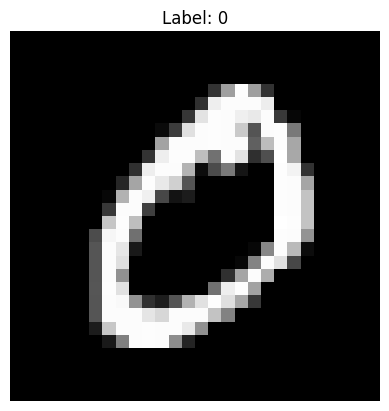

In [12]:

# Get the first image and its label
image, label = train_dataset[1]

# Remove the channel dimension: [1, 28, 28] -> [28, 28]
plt.imshow(image.squeeze(), cmap="gray")

plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [16]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1=nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        selfc.conv2=nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)